# Linear and quadratic discriminant analysis

### Two models separated by one assumption, and what happens when one of them will not fit at all

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Where LDA and QDA come from as generative models, why one shared covariance makes the boundary straight, how to write both as one dial in NumPy, why QDA refuses outright to fit the Dry Bean data and which of the standard repairs actually work, how much labelled projection beats unlabelled projection, and the training-set size below which QDA returns no model at all |
| **You should already know** | [Naive Bayes](../03-naive-bayes/) · [Logistic regression](../01-logistic-regression/) |
| **Datasets** | UCI Dry Bean (13,611 × 16), plus Gaussian data generated twice: once obeying the shared-covariance assumption and once breaking it |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [03-05 Support Vector Machines](../05-support-vector-machines/) |

---

## 1. The idea

[Naive Bayes](../03-naive-bayes/) models what each class looks like and then asks
which class most likely produced the point in front of it. Discriminant analysis
does the same thing, with one change: instead of pretending the features are
independent, it fits a full multivariate normal to each class, correlations and
all.

That leaves one decision, and the whole chapter hangs off it. Do all the classes
share the same covariance matrix, or does each class get its own?

Share it, and you get **linear discriminant analysis**. Every class is the same
ellipsoidal cloud, moved to a different place. The boundary between any two
classes comes out straight.

Give each class its own, and you get **quadratic discriminant analysis**. Clouds
can be stretched and rotated differently, one can be fat and another thin, and
the boundary bends into a conic section.

The trade is the usual one. QDA can express more, and it has many more numbers to
estimate. Section 5 measures what that costs, and the answer is not the one I
assumed when I started writing.

Section 4 is where the chapter earns its keep. Asked to fit the Dry Bean data,
QDA does not score badly. It refuses to produce a model at all, and the error it
throws is a compressed statement of everything the previous paragraph was
gesturing at.

In [1]:
import sys
import pathlib
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

Two data regimes carry this notebook. Both are drawn from Gaussians, because
that is the assumption both methods make, and I want the assumption to be
exactly true or exactly false rather than approximately either.

In the **shared** regime the two classes have the same covariance and differ only
in where their centre sits. That is precisely LDA's model of the world.

In the **unequal** regime the two covariances are rotated differently and the
centres are close together, so most of what separates the classes is the *shape*
of the cloud rather than its position. LDA cannot represent that. QDA can.

In [2]:
def draw(means, covs, n_per_class, seed):
    """Sample `n_per_class` points from each (mean, covariance) pair."""
    rng = np.random.default_rng(seed)
    X = np.vstack([rng.multivariate_normal(m, S, n_per_class) for m, S in zip(means, covs)])
    y = np.repeat(np.arange(len(means)), n_per_class)
    return X, y


# The 2D versions exist so the boundary can be drawn on paper. The covariances are
# written out by hand rather than generated, so you can read the assumption off
# the numbers: identical matrices on the left, mirrored correlation on the right.
SHARED_2D = ([np.array([-1.15, -0.55]), np.array([1.15, 0.55])],
             [np.array([[1.0, 0.78], [0.78, 1.0]])] * 2)

UNEQUAL_2D = ([np.array([-0.35, 0.0]), np.array([0.35, 0.0])],
              [np.array([[1.5, 0.95], [0.95, 1.0]]),
               np.array([[1.5, -0.95], [-0.95, 1.0]])])

for name, (means, covs) in [("shared", SHARED_2D), ("unequal", UNEQUAL_2D)]:
    same = np.allclose(covs[0], covs[1])
    print(f"{name:<8} regime: class covariances identical? {same}")

shared   regime: class covariances identical? True
unequal  regime: class covariances identical? False


shared   regime, 4,000 fresh points: LDA 0.9012   QDA 0.9011   QDA minus LDA -0.0001
unequal  regime, 4,000 fresh points: LDA 0.6129   QDA 0.7916   QDA minus LDA +0.1788


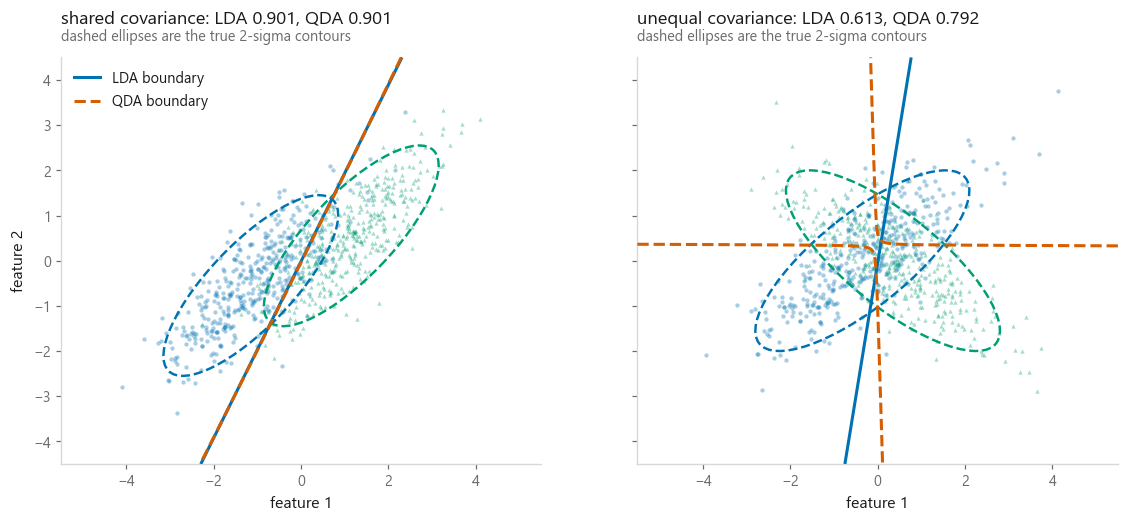

In [3]:
from matplotlib.patches import Ellipse
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)


def cov_ellipse(ax, mean, cov, colour, n_std=2.0):
    """The 2-sigma contour of a 2D Gaussian, so the assumption is visible."""
    values, vectors = np.linalg.eigh(cov)
    order = values.argsort()[::-1]
    values, vectors = values[order], vectors[:, order]
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(values)
    ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False,
                         edgecolor=colour, lw=1.6, ls="--", zorder=4))


fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), sharey=True)
panel_scores = {}

for ax, (name, (means, covs)) in zip(axes, [("shared", SHARED_2D), ("unequal", UNEQUAL_2D)]):
    X_draw, y_draw = draw(means, covs, 400, seed=SEED)
    X_check, y_check = draw(means, covs, 4000, seed=SEED + 1)

    lda = LinearDiscriminantAnalysis().fit(X_draw, y_draw)
    qda = QuadraticDiscriminantAnalysis().fit(X_draw, y_draw)
    panel_scores[name] = (lda.score(X_check, y_check), qda.score(X_check, y_check))

    grid_x, grid_y = np.meshgrid(np.linspace(-5.5, 5.5, 400), np.linspace(-4.5, 4.5, 400))
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]

    for model, colour, dash in [(lda, style.PALETTE[0], "-"), (qda, style.HIGHLIGHT, "--")]:
        surface = model.predict_proba(grid)[:, 1].reshape(grid_x.shape)
        ax.contour(grid_x, grid_y, surface, levels=[0.5], colors=[colour],
                   linewidths=2.0, linestyles=[dash], zorder=5)

    for k, (colour, marker) in enumerate([(style.PALETTE[0], "o"), (style.PALETTE[2], "^")]):
        sel = y_draw == k
        ax.scatter(X_draw[sel, 0], X_draw[sel, 1], s=8, alpha=0.35, c=colour,
                   marker=marker, linewidths=0)
        cov_ellipse(ax, means[k], covs[k], colour)

    ax.set_xlabel("feature 1")
    ax.grid(False)
    style.title(ax, f"{name} covariance: LDA {panel_scores[name][0]:.3f}, "
                    f"QDA {panel_scores[name][1]:.3f}",
                "dashed ellipses are the true 2-sigma contours")

axes[0].set_ylabel("feature 2")
handles = [plt.Line2D([], [], color=style.PALETTE[0], lw=2.0, label="LDA boundary"),
           plt.Line2D([], [], color=style.HIGHLIGHT, lw=2.0, ls="--", label="QDA boundary")]
axes[0].legend(handles=handles, loc="upper left")
style.save(fig, FIG / "fig-01-two-regimes.png")

for name, (a, b) in panel_scores.items():
    print(f"{name:<8} regime, 4,000 fresh points: LDA {a:.4f}   QDA {b:.4f}   "
          f"QDA minus LDA {b - a:+.4f}")

The left panel is the situation LDA was designed for, and the two boundaries sit
almost on top of each other: QDA is allowed to bend but has nothing to bend
around, so it fits a curve that is nearly straight.

The right panel is the one to look at. The two ellipses cross, the centres are
close, and a straight line cannot separate an X-shaped arrangement. QDA's
boundary is a hyperbola and it goes where the data goes.

## 2. The maths

Bayes' theorem, same starting point as naive Bayes:

$$P(c \mid x) \;\propto\; \pi_c \, f_c(x)$$

where $\pi_c$ is the class prior and $f_c$ is the density of class $c$. Discriminant
analysis picks the multivariate normal for $f_c$:

$$f_c(x) = \frac{1}{(2\pi)^{d/2} |\Sigma_c|^{1/2}}
           \exp\!\Big(\!-\tfrac{1}{2}(x - \mu_c)^\top \Sigma_c^{-1} (x - \mu_c)\Big)$$

Take logs, drop everything that does not depend on the class, and you have the
**quadratic discriminant function**:

$$\delta_c(x) = -\tfrac{1}{2}\log|\Sigma_c|
                -\tfrac{1}{2}(x-\mu_c)^\top \Sigma_c^{-1}(x-\mu_c)
                + \log \pi_c$$

Predict the class with the largest $\delta_c$. That is QDA in one line.

### Where the straight boundary comes from

Now assume every class shares one covariance, $\Sigma_c = \Sigma$. Expand the
middle term:

$$(x-\mu_c)^\top \Sigma^{-1}(x-\mu_c)
  = \underbrace{x^\top \Sigma^{-1} x}_{\text{same for every class}}
  - 2\,x^\top \Sigma^{-1}\mu_c + \mu_c^\top \Sigma^{-1}\mu_c$$

The first term does not carry a class subscript, and neither does $\log|\Sigma|$
any more. Both are identical for every class, so both cancel when you compare two
classes. What survives is

$$\delta_c(x) = x^\top \Sigma^{-1}\mu_c
               - \tfrac{1}{2}\mu_c^\top \Sigma^{-1}\mu_c
               + \log \pi_c$$

which is **affine in $x$**. The comparison between two classes is a linear
function set to zero, which is a hyperplane. That cancellation is the entire
reason LDA draws straight lines, and it happens in the algebra rather than in any
code.

### Counting the parameters, because section 5 depends on it

With $d$ features and $K$ classes:

| | means | covariance | total |
|---|---|---|---|
| LDA | $Kd$ | $\tfrac{1}{2}d(d+1)$ | $Kd + \tfrac{1}{2}d(d+1)$ |
| QDA | $Kd$ | $K \cdot \tfrac{1}{2}d(d+1)$ | $Kd + \tfrac{K}{2}d(d+1)$ |

The covariance term is quadratic in $d$ and QDA pays it once per class. Every one
of those numbers has to be estimated from data, and a covariance estimated from
too few rows is noise wearing a matrix's clothing.

In [4]:
def parameter_count(d, k):
    covariance = d * (d + 1) // 2
    return {"LDA": k * d + covariance, "QDA": k * d + k * covariance}


print("free parameters, 2 classes")
for d in [2, 10, 16, 30]:
    counts = parameter_count(d, 2)
    print(f"  d={d:<3} LDA {counts['LDA']:>5,}   QDA {counts['QDA']:>5,}   "
          f"ratio {counts['QDA'] / counts['LDA']:.2f}x")

print("\nfree parameters, 7 classes (the Dry Bean setting)")
counts = parameter_count(16, 7)
print(f"  d=16  LDA {counts['LDA']:,}   QDA {counts['QDA']:,}   "
      f"ratio {counts['QDA'] / counts['LDA']:.2f}x")

# Section 5 runs at d=10 with 2 classes, and quotes these two numbers.
print(f"\nat d=10 with 2 classes the covariance alone costs LDA "
      f"{parameter_count(10, 2)['LDA'] - 2 * 10} numbers and QDA "
      f"{parameter_count(10, 2)['QDA'] - 2 * 10}")

free parameters, 2 classes
  d=2   LDA     7   QDA    10   ratio 1.43x
  d=10  LDA    75   QDA   130   ratio 1.73x
  d=16  LDA   168   QDA   304   ratio 1.81x
  d=30  LDA   525   QDA   990   ratio 1.89x

free parameters, 7 classes (the Dry Bean setting)
  d=16  LDA 248   QDA 1,064   ratio 4.29x

at d=10 with 2 classes the covariance alone costs LDA 55 numbers and QDA 110


## 3. From scratch

One class covers both methods, because the only difference is which covariance
matrix goes into the discriminant function. So rather than an either-or flag I
give it a dial. `pool` says how far each class covariance gets dragged towards
the pooled one:

$$\Sigma_c(\lambda) = (1-\lambda)\,\Sigma_c + \lambda\,\Sigma_{\text{pooled}}$$

At `pool=0` every class keeps its own matrix and this is QDA. At `pool=1` every
class gets the same matrix and this is LDA. Writing it this way costs one extra
line and it pays for itself twice: it makes the point that LDA is the same
algorithm handed the same matrix `K` times, and section 4 needs the values in
between.

I write the quadratic form out in full whatever `pool` is, even though at
`pool=1` two of its terms are known to cancel.

In [5]:
class DiscriminantAnalysisScratch:
    """LDA, QDA, and everything between, in one class.

    `pool` is the fraction of the pooled covariance mixed into each class
    covariance. 0 is QDA, 1 is LDA.
    """

    def __init__(self, pool=1.0):
        if not 0.0 <= pool <= 1.0:
            raise ValueError("pool must lie between 0 and 1")
        self.pool = pool

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        n, d = X.shape
        self.classes_ = np.unique(y)

        priors, means, per_class, scatter = [], [], [], np.zeros((d, d))
        for c in self.classes_:
            rows = X[y == c]
            priors.append(len(rows) / n)
            means.append(rows.mean(axis=0))
            centred = rows - means[-1]
            # Unbiased within-class covariance, matching scikit-learn's convention.
            per_class.append(centred.T @ centred / (len(rows) - 1))
            scatter += centred.T @ centred

        self.priors_ = np.array(priors)
        self.means_ = np.array(means)
        # The pooled estimate divides by n - K, not n - 1: each class already spent
        # one degree of freedom on its own mean.
        pooled = scatter / (n - len(self.classes_))
        self.covariances_ = [(1 - self.pool) * S + self.pool * pooled for S in per_class]
        return self

    def decision_scores(self, X):
        """delta_c(x) for every class, unnormalised log posterior."""
        X = np.asarray(X, float)
        out = np.empty((len(X), len(self.classes_)))
        for i, (mean, cov, prior) in enumerate(zip(self.means_, self.covariances_,
                                                   self.priors_)):
            diff = X - mean
            _, logdet = np.linalg.slogdet(cov)
            # solve rather than inv: same answer, better conditioned, and it is the
            # habit worth having when d is large.
            solved = np.linalg.solve(cov, diff.T).T
            mahalanobis = np.einsum("ij,ij->i", diff, solved)
            out[:, i] = -0.5 * (logdet + mahalanobis) + np.log(prior)
        return out

    def predict(self, X):
        return self.classes_[self.decision_scores(X).argmax(axis=1)]

The check runs on ten-dimensional Gaussian data rather than on Dry Bean, because
the bean columns are close to collinear and a near-singular covariance would turn
a correctness check into a conditioning check. Section 4 deals with that
separately.

In [6]:
D = 10


def spd(d, seed, spread=8.0):
    """A random symmetric positive-definite matrix with controlled conditioning."""
    q, r = np.linalg.qr(np.random.default_rng(seed).normal(size=(d, d)))
    q = q * np.sign(np.diag(r))                 # pin the sign so the seed is meaningful
    return (q * np.geomspace(1.0, spread, d)) @ q.T


def separated_means(cov, distance, d, seed):
    """Two means a chosen Mahalanobis distance apart under `cov`.

    Fixing the distance rather than the raw offset means the difficulty of the
    problem does not drift when the covariance changes.
    """
    raw = np.random.default_rng(seed).normal(size=d)
    scale = distance / np.sqrt(raw @ np.linalg.solve(cov, raw))
    return [np.zeros(d), raw * scale]


SHARED_COV = spd(D, seed=11, spread=6.0)
SHARED_ND = (separated_means(SHARED_COV, 2.3, D, seed=12), [SHARED_COV, SHARED_COV])

COV_A, COV_B = spd(D, seed=21, spread=9.0), spd(D, seed=22, spread=9.0)
UNEQUAL_ND = (separated_means((COV_A + COV_B) / 2, 0.9, D, seed=23), [COV_A, COV_B])

X_check, y_check = draw(*SHARED_ND, 4000, seed=101)


def softmax(scores):
    shifted = scores - scores.max(axis=1, keepdims=True)
    weights = np.exp(shifted)
    return weights / weights.sum(axis=1, keepdims=True)


rows = []
for label, pool, reference in [("pool=1, should be LDA", 1.0, LinearDiscriminantAnalysis()),
                               ("pool=0, should be QDA", 0.0, QuadraticDiscriminantAnalysis())]:
    mine = DiscriminantAnalysisScratch(pool=pool).fit(X_check, y_check)
    reference.fit(X_check, y_check)
    rows.append({
        "setting": label,
        "predictions agree": (mine.predict(X_check) == reference.predict(X_check)).mean(),
        "max mean gap": np.abs(mine.means_ - reference.means_).max(),
        "max probability gap": np.abs(softmax(mine.decision_scores(X_check))
                                      - reference.predict_proba(X_check)).max(),
    })

print(pd.DataFrame(rows).to_string(index=False))

              setting  predictions agree  max mean gap  max probability gap
pool=1, should be LDA                1.0           0.0         2.553513e-15
pool=0, should be QDA                1.0           0.0         1.243450e-14


Two conventions had to match for those probability gaps to come out small. QDA
divides each class covariance by $n_c - 1$, and LDA divides the pooled scatter by
$n - K$ rather than $n - 1$, because every class already spent one degree of
freedom locating its own mean. Get either denominator wrong and the predictions
still mostly agree while the probabilities drift, which is the kind of bug that
survives a smoke test.

Now the claim from section 2, checked rather than asserted. If LDA's discriminant
really is affine, then the difference between the two class scores must equal
$x^\top w + b$ for exactly the $w$ and $b$ the algebra predicts.

In [7]:
lda_scratch = DiscriminantAnalysisScratch(pool=1.0).fit(X_check, y_check)
sigma = lda_scratch.covariances_[0]
mu0, mu1 = lda_scratch.means_
p0, p1 = lda_scratch.priors_

w = np.linalg.solve(sigma, mu1 - mu0)
b = -0.5 * (mu1 @ np.linalg.solve(sigma, mu1) - mu0 @ np.linalg.solve(sigma, mu0))
b += np.log(p1 / p0)

scores = lda_scratch.decision_scores(X_check)
lda_gap = scores[:, 1] - scores[:, 0]
print(f"largest disagreement between LDA's score gap and the affine formula: "
      f"{np.abs(lda_gap - (X_check @ w + b)).max():.3e}")


def best_affine_residual(X, target):
    """How far the best possible straight-line fit still misses `target`."""
    design = np.c_[X, np.ones(len(X))]
    solution, *_ = np.linalg.lstsq(design, target, rcond=None)
    return np.abs(design @ solution - target).max()


qda_scratch = DiscriminantAnalysisScratch(pool=0.0).fit(X_check, y_check)
qda_scores = qda_scratch.decision_scores(X_check)
qda_gap = qda_scores[:, 1] - qda_scores[:, 0]

print(f"the same measurement for QDA, where the derivation says it must fail: "
      f"{best_affine_residual(X_check, qda_gap):.3e}")
print("that second number is the residual of the best straight line anyone could")
print("fit to QDA's score gap. It is not small, which is what 'quadratic' means.")

largest disagreement between LDA's score gap and the affine formula: 1.066e-14
the same measurement for QDA, where the derivation says it must fail: 9.159e-01
that second number is the residual of the best straight line anyone could
fit to QDA's score gap. It is not small, which is what 'quadratic' means.


## 4. In practice, on the beans

### The crash

[Dry Bean](../../CURRICULUM.md) is seven varieties measured from photographs, and
every one of its columns is a geometric quantity computed from the same outline.
It is the workhorse dataset of this book, LDA handles it without a murmur, and
QDA cannot fit it at all.

Not fits-it-badly. Will not return a model. I catch the exception so the notebook
survives, and I print it in full, because recognising this message on sight is
worth more than most of what a chapter like this can teach you.

In [8]:
X_bean, y_bean = datasets.dry_bean()
bean_values = X_bean.values.astype(float)
bean_labels = y_bean.values
n_bean, d_bean = bean_values.shape
sizes_by_class = y_bean.value_counts()

print(f"{n_bean:,} beans, {d_bean} measurements, {y_bean.nunique()} varieties")
print(f"smallest class is {sizes_by_class.index[-1]} with {sizes_by_class.iloc[-1]:,} rows, "
      f"which is {sizes_by_class.iloc[-1] / d_bean:.0f} rows for every column")

try:
    QuadraticDiscriminantAnalysis().fit(bean_values, bean_labels)
    print("\nQDA fitted without complaint")
except np.linalg.LinAlgError as failure:
    print(f"\nQDA raised {type(failure).__name__}:")
    print(f"    {failure}")

bean_lda = LinearDiscriminantAnalysis().fit(bean_values, bean_labels)
print(f"\nLDA, same array, same call: fitted. "
      f"Training accuracy {bean_lda.score(bean_values, bean_labels):.4f}")

13,611 beans, 16 measurements, 7 varieties
smallest class is BOMBAY with 522 rows, which is 33 rows for every column

QDA raised LinAlgError:
    The covariance matrix of class BARBUNYA is not full rank. Increase the value of `reg_param` to reduce the collinearity.

LDA, same array, same call: fitted. Training accuracy 0.9050


The obvious explanation is that some class is too small to estimate a covariance
matrix from. The printed row count kills that idea before it starts: even the
smallest variety has far more rows than columns, and the ratio is printed above.
The problem is not how many rows there are, it is that the rows do not point in
enough directions.

### What is actually singular

A covariance matrix is invertible when the cloud it describes has genuine extent
in every direction. If two columns are the same measurement in different units,
the cloud is flat in that direction, the covariance has a zero eigenvalue, and
there is nothing to invert. scikit-learn checks for this before it tries, by
counting how many eigenvalues clear a tolerance.

So I count them too, per class and pooled, and put the condition number next to
them. The condition number is the largest eigenvalue over the smallest, and it is
roughly how many digits of precision the inversion destroys.

In [9]:
TOL = QuadraticDiscriminantAnalysis().tol       # the threshold the rank check uses
varieties = np.unique(bean_labels)

spectra, scatter, diagnosis = {}, np.zeros((d_bean, d_bean)), []
for variety in varieties:
    rows = bean_values[bean_labels == variety]
    centred = rows - rows.mean(axis=0)
    scatter += centred.T @ centred
    # Eigenvalues of the class covariance, via the SVD of the centred rows. Same
    # route scikit-learn takes, so the count below is the count it acts on.
    eig = np.linalg.svd(centred, compute_uv=False) ** 2 / (len(rows) - 1)
    spectra[variety] = eig
    diagnosis.append({"class": variety, "rows": len(rows),
                      "numerical rank": np.linalg.matrix_rank(np.cov(rows, rowvar=False)),
                      "eigenvalues above tol": int((eig > TOL).sum()),
                      "condition number": eig[0] / eig[-1]})

pooled_cov = scatter / (n_bean - len(varieties))
pooled_eig = np.linalg.eigvalsh(pooled_cov)[::-1]
spectra["pooled"] = pooled_eig
diagnosis.append({"class": "pooled, what LDA uses", "rows": n_bean,
                  "numerical rank": np.linalg.matrix_rank(pooled_cov),
                  "eigenvalues above tol": int((pooled_eig > TOL).sum()),
                  "condition number": pooled_eig[0] / pooled_eig[-1]})

diagnosis = pd.DataFrame(diagnosis)
print(f"a full-rank fit needs all {d_bean} columns to survive, and scikit-learn counts a "
      f"direction as surviving when its eigenvalue exceeds tol = {TOL:g}\n")
print(diagnosis.to_string(index=False, formatters={"condition number": "{:.2e}".format}))

per_class = diagnosis.iloc[:-1]
pooled_condition = pooled_eig[0] / pooled_eig[-1]
print(f"\nbest any single class manages: {per_class['eigenvalues above tol'].max()} "
      f"of {d_bean} directions, and {per_class['numerical rank'].max()} of {d_bean} by "
      f"numerical rank")
print(f"pooled: {int(diagnosis['eigenvalues above tol'].iloc[-1])} and "
      f"{int(diagnosis['numerical rank'].iloc[-1])} of {d_bean}")
print(f"worst class condition number {per_class['condition number'].max():.2e}, "
      f"pooled {pooled_condition:.2e}, so pooling buys a factor of "
      f"{per_class['condition number'].max() / pooled_condition:,.0f}")

a full-rank fit needs all 16 columns to survive, and scikit-learn counts a direction as surviving when its eigenvalue exceeds tol = 0.0001

                class  rows  numerical rank  eigenvalues above tol condition number
             BARBUNYA  1322              11                      8         4.46e+19
               BOMBAY   522               9                      7         1.13e+21
                 CALI  1630              10                      7         1.27e+20
             DERMASON  3546              11                      7         8.60e+18
                HOROZ  1928              11                      8         3.80e+19
                SEKER  2027              11                      8         1.88e+19
                 SIRA  2636              11                      7         3.14e+19
pooled, what LDA uses 13611              12                      9         5.49e+17

best any single class manages: 8 of 16 directions, and 11 of 16 by numerical rank
pooled: 9 and 12 of 1

Two things in that table are worth stopping on.

Pooling helps enormously and does not fix the problem. The pooled matrix has more
usable directions and a condition number smaller by the printed factor, but it is
still short of the column count. So the reason LDA runs and QDA does not is
narrower than "pooling makes it invertible". It is that scikit-learn's LDA
quietly drops the directions it cannot use and carries on, while its QDA treats
the same situation as an error and stops. One library made a judgement call in
each direction, and only one of them tells you.

The condition numbers are the part I did not expect. Losing that many orders of
magnitude means the inverse is arithmetic performed on digits that are not there.

And one thing the exception does not tell you, which the table does. The error
names BARBUNYA, and BARBUNYA is not the worst row in the table. It is one of the
three best on the tolerance count. The printed worst condition number belongs to
BOMBAY, which is also the smallest variety and the only one whose numerical rank
drops to single figures. On the tolerance count BOMBAY does not stand out at all:
four varieties tie at seven directions, and BARBUNYA is not one of them.

BARBUNYA is simply the first variety the rank check reaches, because the classes
are enumerated in sorted order and the check raises on the first failure rather
than surveying all seven. So the name in the message answers "which class did we
get to first", not "which class is the problem", and treating it as a diagnosis
would send you to the wrong bean.

Now the cause itself. Correlated pairs are the usual suspect, but a pair being
correlated is a much weaker statement than a column being reconstructable from
all the others at once. The second measurement is the one that matters, so I
regress each column on the remaining fifteen, inside a single class.

In [10]:
correlations = X_bean.corr().abs()
upper = np.triu(np.ones(correlations.shape, dtype=bool), k=1)
print("the most redundant column pairs, across the whole dataset:")
for (a, b), value in correlations.where(upper).stack().sort_values(ascending=False).head(4).items():
    print(f"  {a} and {b}: {value:.4f}")

smallest = sizes_by_class.index[-1]
inside = bean_values[bean_labels == smallest]
inside = (inside - inside.mean(axis=0)) / inside.std(axis=0)

explained = []
for j, column in enumerate(X_bean.columns):
    design = np.c_[np.delete(inside, j, axis=1), np.ones(len(inside))]
    coefficients, *_ = np.linalg.lstsq(design, inside[:, j], rcond=None)
    residual = inside[:, j] - design @ coefficients
    explained.append({"column": column,
                      "R2 from the other columns": 1 - residual.var() / inside[:, j].var()})

explained = pd.DataFrame(explained).sort_values("R2 from the other columns", ascending=False)
print(f"\ninside {smallest} alone, how well each column is predicted by the other "
      f"{d_bean - 1}:")
print(explained.head(5).round(6).to_string(index=False))

the most redundant column pairs, across the whole dataset:
  Area and ConvexArea: 0.9999
  Compactness and ShapeFactor3: 0.9987
  Perimeter and EquivDiameter: 0.9914
  AspectRation and Compactness: 0.9877

inside BOMBAY alone, how well each column is predicted by the other 15:
         column  R2 from the other columns
    Compactness                   0.999999
  EquivDiameter                   0.999999
   ShapeFactor3                   0.999998
MajorAxisLength                   0.999996
           Area                   0.999995


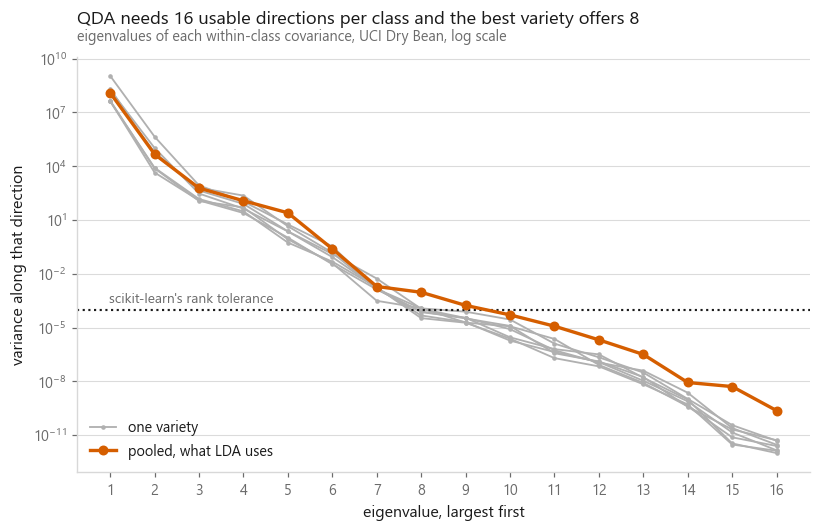

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.9))
positions = np.arange(1, d_bean + 1)
for i, variety in enumerate(varieties):
    ax.plot(positions, spectra[variety], color=style.NEUTRAL, lw=1.2, marker=".",
            markersize=4, zorder=2, label="one variety" if i == 0 else None)
ax.plot(positions, spectra["pooled"], color=style.HIGHLIGHT, lw=2.2,
        marker=style.MARKERS[0], zorder=3, label="pooled, what LDA uses")
ax.axhline(TOL, color=style.INK, ls=":", lw=1.4)
ax.annotate("scikit-learn's rank tolerance", xy=(0.98, TOL), xytext=(0, 5),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xlabel("eigenvalue, largest first")
ax.set_ylabel("variance along that direction")
ax.legend(loc="lower left")
widest = int(max((spectra[v] > TOL).sum() for v in varieties))
style.title(ax, f"QDA needs {d_bean} usable directions per class and the best variety offers {widest}",
            "eigenvalues of each within-class covariance, UCI Dry Bean, log scale")
style.save(fig, FIG / "fig-02-singular-covariances.png")

The chart is the crash. Every line falls off a cliff, and the flat tail below the
dotted line is a set of directions in which a bean does not vary at all. Those
directions exist because the columns were computed from one another:
`EquivDiameter` is a function of `Area`, `Compactness` is a ratio of two axis
lengths, the shape factors are algebra performed on the same handful of
quantities. The regression above puts a number on it, and that number is as close
to one as floating point gets.

### The repair: regularised discriminant analysis

The method that fixes this is older than the error message. Regularised
discriminant analysis takes the class covariance and mixes something better
conditioned into it. There are two sensible things to mix in, and they are not
the same thing:

$$\tilde\Sigma_c = (1-\gamma)\,\Sigma_c + \gamma\,I
\qquad\text{or}\qquad
\tilde\Sigma_c = (1-\lambda)\,\Sigma_c + \lambda\,\Sigma_{\text{pooled}}$$

The left one drags every class towards a sphere. The right one drags every class
towards the shared matrix, which is LDA's matrix. scikit-learn's `reg_param` is
the left one. The `pool` dial from section 3 is the right one. Both stop the
inversion from amplifying noise, and only one of them has LDA at the far end.

The sweep below fits QDA at every `reg_param` on a grid and records what happened,
including the values where nothing happened.

In [12]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

REG_GRID = [0.0, 1e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2,
            0.1, 0.2, 0.35, 0.5, 0.7, 0.85, 0.95, 0.99]

sweep = []
for reg in REG_GRID:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")     # cross_val_score is loud about failed fits
            score = cross_val_score(QuadraticDiscriminantAnalysis(reg_param=reg),
                                    bean_values, bean_labels, cv=folds).mean()
        sweep.append({"reg_param": reg, "accuracy": score})
    except (ValueError, np.linalg.LinAlgError):
        sweep.append({"reg_param": reg, "accuracy": np.nan})

sweep = pd.DataFrame(sweep)
lda_cv = cross_val_score(LinearDiscriminantAnalysis(), bean_values, bean_labels, cv=folds).mean()
print(sweep.to_string(index=False, na_rep="refused to fit",
                      formatters={"reg_param": "{:g}".format, "accuracy": "{:.4f}".format}))

working = sweep.dropna()
best_reg_row = working.loc[working["accuracy"].idxmax()]
best_reg = best_reg_row["reg_param"]
heaviest = working.iloc[-1]
print(f"\nLDA on the same folds: {lda_cv:.4f}")
print(f"smallest reg_param that produces a model: {working['reg_param'].iloc[0]:g}")
print(f"scikit-learn's rank tolerance, tol:       {TOL:g}")
print(f"best on the grid: reg_param {best_reg:g} at {best_reg_row['accuracy']:.4f}, "
      f"{best_reg_row['accuracy'] - lda_cv:+.4f} against LDA")
print(f"heaviest shrinkage tried, reg_param {heaviest['reg_param']:g}: "
      f"{heaviest['accuracy']:.4f}, {heaviest['accuracy'] - lda_cv:+.4f} against LDA")

reg_param       accuracy
        0 refused to fit
    1e-06 refused to fit
    1e-05 refused to fit
    3e-05 refused to fit
   0.0001         0.9163
   0.0003         0.9143
    0.001         0.9130
    0.003         0.9113
     0.01         0.9109
     0.03         0.9103
      0.1         0.9084
      0.2         0.9071
     0.35         0.9059
      0.5         0.9054
      0.7         0.9027
     0.85         0.8982
     0.95         0.8954
     0.99         0.8930

LDA on the same folds: 0.9046
smallest reg_param that produces a model: 0.0001
scikit-learn's rank tolerance, tol:       0.0001
best on the grid: reg_param 0.0001 at 0.9163, +0.0117 against LDA
heaviest shrinkage tried, reg_param 0.99: 0.8930, -0.0116 against LDA


Those last two printed lines are the whole argument about which dial you are
turning.

The smallest `reg_param` that produces a model is the same number as the rank
tolerance, and that is not a coincidence. Adding $\gamma$ to every eigenvalue
lifts the flat tail from the previous chart above the dotted line, so the rank
check passes as soon as $\gamma$ clears it. Regularisation here is not making the
estimate better in some vague sense, it is moving a specific set of eigenvalues
past a specific threshold.

And the far end of the sweep is not LDA. If `reg_param` interpolated between QDA
and LDA, the heaviest shrinkage would land on LDA's score. The printed gap says it
lands well below, because a sphere is not the pooled covariance. Shrinking towards
a sphere throws away every correlation the data has, which on sixteen columns
built out of each other is most of the information.

The `pool` dial does interpolate to LDA, by construction. Here is the same sweep
with that dial instead, using the class from section 3.

In [13]:
def fold_accuracy(build):
    """Mean accuracy over the same five folds, for anything with fit and predict."""
    scores = []
    for train, test in folds.split(bean_values, bean_labels):
        model = build().fit(bean_values[train], bean_labels[train])
        scores.append((model.predict(bean_values[test]) == bean_labels[test]).mean())
    return float(np.mean(scores))


POOL_GRID = np.round(np.linspace(0.0, 1.0, 21), 2)
pool_curve = [fold_accuracy(lambda p=p: DiscriminantAnalysisScratch(pool=p)) for p in POOL_GRID]

best_pool = float(POOL_GRID[int(np.argmax(pool_curve))])
print(f"pool=0, no regularisation at all, on the matrices scikit-learn refused: "
      f"{pool_curve[0]:.4f}")
print(f"pool=1, from scratch: {pool_curve[-1]:.4f}   "
      f"scikit-learn's LDA on the same folds: {lda_cv:.4f}")
print(f"best on the grid: pool {best_pool:g} at {max(pool_curve):.4f}, "
      f"{max(pool_curve) - lda_cv:+.4f} against LDA")

# The pool=0 fit runs, but should it be trusted? Shake the data in its fourth
# significant digit and count how many predictions change their mind.
rng = np.random.default_rng(SEED)
jitter = 1 + rng.normal(scale=1e-4, size=bean_values.shape)
print("\nafter perturbing every measurement by about one part in ten thousand:")
for pool in [0.0, best_pool]:
    steady = DiscriminantAnalysisScratch(pool=pool).fit(bean_values, bean_labels).predict(bean_values)
    shaken = DiscriminantAnalysisScratch(pool=pool).fit(bean_values * jitter,
                                                        bean_labels).predict(bean_values)
    print(f"  pool={pool:<4g} {(steady != shaken).sum():>4} of {n_bean:,} predictions move")

pool=0, no regularisation at all, on the matrices scikit-learn refused: 0.9115
pool=1, from scratch: 0.9046   scikit-learn's LDA on the same folds: 0.9046
best on the grid: pool 0.4 at 0.9163, +0.0117 against LDA

after perturbing every measurement by about one part in ten thousand:
  pool=0     144 of 13,611 predictions move
  pool=0.4    61 of 13,611 predictions move


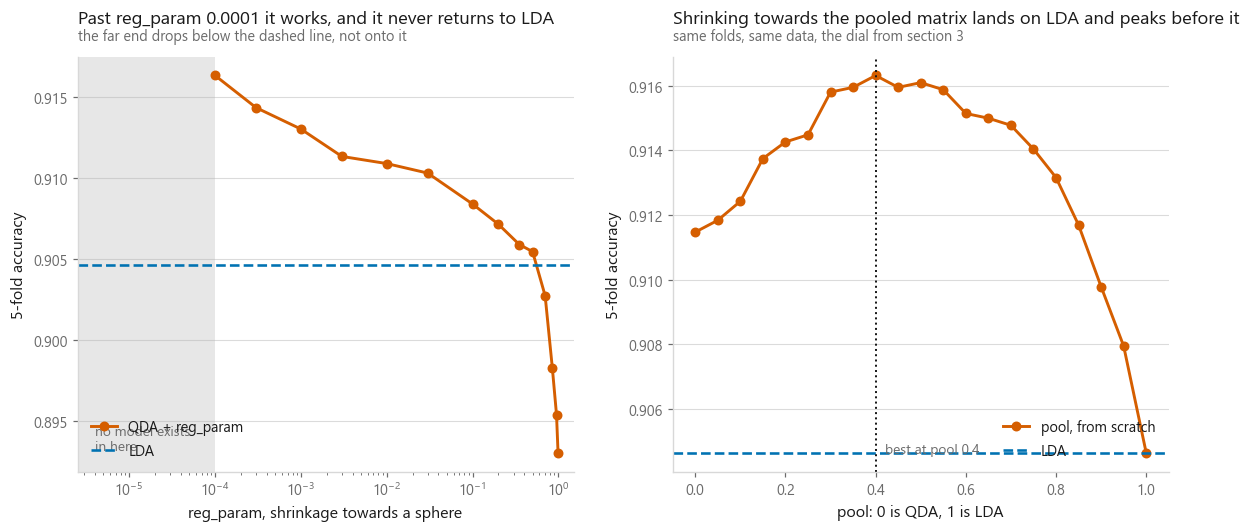

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9))

ax = axes[0]
floor = working["reg_param"].min() / 40
ax.axvspan(floor, working["reg_param"].min(), color=style.NEUTRAL, alpha=0.3, linewidth=0)
ax.annotate("no model exists\nin here", xy=(floor * 1.6, working["accuracy"].min()),
            fontsize=9, color=style.MUTED, va="bottom")
ax.plot(working["reg_param"], working["accuracy"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], label="QDA + reg_param")
ax.axhline(lda_cv, color=style.PALETTE[0], ls="--", lw=1.7, label="LDA")
ax.set_xscale("log")
ax.set_xlim(floor, 1.5)
ax.set_xlabel("reg_param, shrinkage towards a sphere")
ax.set_ylabel("5-fold accuracy")
ax.legend(loc="lower left")
style.title(ax, f"Past reg_param {working['reg_param'].iloc[0]:g} it works, and it never returns to LDA",
            "the far end drops below the dashed line, not onto it")

ax = axes[1]
ax.plot(POOL_GRID, pool_curve, color=style.HIGHLIGHT, marker=style.MARKERS[0],
        label="pool, from scratch")
ax.axhline(lda_cv, color=style.PALETTE[0], ls="--", lw=1.7, label="LDA")
ax.axvline(best_pool, color=style.INK, ls=":", lw=1.3)
ax.annotate(f"best at pool {best_pool:g}", xy=(best_pool, min(pool_curve)), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xlabel("pool: 0 is QDA, 1 is LDA")
ax.set_ylabel("5-fold accuracy")
ax.legend(loc="lower right")
style.title(ax, f"Shrinking towards the pooled matrix lands on LDA and peaks before it",
            "same folds, same data, the dial from section 3")

style.save(fig, FIG / "fig-03-regularisation.png")

The left panel is the practical picture and the right panel is the honest one.

On the right, the curve ends exactly on LDA's line, which is the check that the
`pool` dial does what the algebra says. The peak sits strictly inside the
interval, so the best model on this data is neither of the two named methods. That
is the actual content of regularised discriminant analysis, and it is why the
choice between LDA and QDA is better read as a choice of where to sit on a line
than as a choice between two boxes.

The left-hand end of that same curve is uncomfortable. `pool=0` is plain QDA on
the very matrices scikit-learn refused to invert, and it does not fall over. It
scores respectably. So the exception is a guard rail rather than a verdict: the
library declines to hand you an answer whose digits it cannot vouch for, which is
the correct thing for a library to do, and it is not the same as saying the answer
would have been wrong.

The perturbation test is why I would still not take that answer. Nudging each
measurement in its fourth significant digit, which is less than the noise in
measuring a bean from a photograph, moves well over twice as many predictions at
`pool=0` as at the peak. The unregularised fit is balanced on numerical
accidents. It happens to be standing up.

### The other repair: give it fewer columns

Regularising the matrix is one way out. Removing the redundancy is the other, and
it is the one people reach for first. Two versions, both worth trying: drop
columns that duplicate another column, or replace all of them with principal
components. Neither behaves the way I assumed.

In [15]:
def qda_accuracy(matrix, steps=()):
    """5-fold accuracy for plain QDA behind `steps`, or None if it will not fit.

    Everything goes through a pipeline so any transformer is fitted on the
    training fold only. Fitting PCA on all the rows first and cross-validating
    afterwards would quietly hand the test fold its own variance structure.
    """
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")     # cross_val_score is loud about failed fits
            return cross_val_score(make_pipeline(*steps, QuadraticDiscriminantAnalysis()),
                                   matrix, bean_labels, cv=folds).mean()
    except (ValueError, np.linalg.LinAlgError):
        return None


def keep_uncorrelated(threshold):
    """Walk the columns left to right, keeping any that no kept column mirrors."""
    kept = []
    for column in X_bean.columns:
        if all(correlations.loc[column, other] < threshold for other in kept):
            kept.append(column)
    return kept


dropped = []
for threshold in [0.99, 0.95, 0.9, 0.8]:
    kept = X_bean[keep_uncorrelated(threshold)].values
    dropped.append({"drop above |r|": threshold, "columns kept": kept.shape[1],
                    "raw": qda_accuracy(kept),
                    "standardised first": qda_accuracy(kept, steps=[StandardScaler()])})

print("route one, throw away duplicated columns")
print(pd.DataFrame(dropped).to_string(index=False, na_rep="refused to fit"))

reduced = []
for k in [4, 6, 8, 9, 10, 12, d_bean]:
    reduced.append({"components": k,
                    "accuracy": qda_accuracy(bean_values, steps=[
                        StandardScaler(), PCA(n_components=k, random_state=SEED)])})
print("\nroute two, principal components")
print(pd.DataFrame(reduced).to_string(index=False, na_rep="refused to fit"))

pca_scores = [r for r in reduced if r["accuracy"] is not None]
best_pca = max(pca_scores, key=lambda r: r["accuracy"])
best_k = int(best_pca["components"])
print(f"\nbest PCA setting: {best_k} components at {best_pca['accuracy']:.4f}, "
      f"{best_pca['accuracy'] - lda_cv:+.4f} against LDA")

route one, throw away duplicated columns
 drop above |r|  columns kept  raw  standardised first
           0.99            13 None      refused to fit
           0.95            10 None      refused to fit
           0.90             8 None            0.915436
           0.80             6 None            0.919036



route two, principal components
 components       accuracy
          4       0.887223
          6       0.917493
          8       0.914187
          9       0.912350
         10 refused to fit
         12 refused to fit
         16 refused to fit

best PCA setting: 6 components at 0.9175, +0.0129 against LDA


Route one fails on the raw columns at every threshold I tried, including the ones
that discard half the dataset. That surprised me until I looked at the units.
`Area` runs into the tens of thousands and `ShapeFactor2` sits near zero, so the
smallest eigenvalue of any matrix containing both is below the tolerance on
account of scale alone, before collinearity gets a say. Standardising first
separates the two effects, and then dropping columns does start to work, but only
once the threshold is aggressive enough to remove a good half of them.

Route two works and it wins. Principal components are orthogonal by construction,
so the redundancy is gone rather than reduced. The failures in that table are the
trailing components, which carry so little variance that they fall under the
tolerance themselves. Keeping the whole set puts the problem back exactly as it
was, which is the neatest confirmation that PCA is not doing anything magic here.
It is deleting the flat directions, and the flat directions were the crash.

### The leaderboard

Everything that has come up so far, on the same folds, with the failure left in
the table where it belongs rather than quietly dropped.

In [16]:
contenders = {
    "LDA": LinearDiscriminantAnalysis(),
    "LDA + shrinkage": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    "QDA, as it comes": QuadraticDiscriminantAnalysis(),
    f"QDA + reg_param {best_reg:g}": QuadraticDiscriminantAnalysis(reg_param=best_reg),
    f"QDA on {best_k} principal components": make_pipeline(
        StandardScaler(), PCA(n_components=best_k, random_state=SEED),
        QuadraticDiscriminantAnalysis()),
    "Gaussian naive Bayes": GaussianNB(),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
}

board = []
for name, estimator in contenders.items():
    started = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            guess = cross_val_predict(estimator, bean_values, bean_labels, cv=folds)
        board.append({"model": name,
                      "accuracy": accuracy_score(bean_labels, guess),
                      "balanced": balanced_accuracy_score(bean_labels, guess),
                      "seconds": time.perf_counter() - started})
    except (ValueError, np.linalg.LinAlgError):
        board.append({"model": name, "accuracy": np.nan, "balanced": np.nan,
                      "seconds": time.perf_counter() - started})

board = pd.DataFrame(board).sort_values("accuracy", ascending=False, na_position="last")
print(board.round(4).to_string(index=False, na_rep="did not fit"))

                        model    accuracy    balanced  seconds
          logistic regression      0.9234      0.9341   0.7275
QDA on 6 principal components      0.9175      0.9312   0.1080
       QDA + reg_param 0.0001      0.9163      0.9297   0.1161
                          LDA      0.9046      0.9167   0.1090
              LDA + shrinkage      0.9029      0.9144   0.1210
         Gaussian naive Bayes      0.7641      0.7670   0.0709
             QDA, as it comes did not fit did not fit   0.0161


Read the ordering rather than the individual gaps, and compare it against the
ordering the two [earlier](../01-logistic-regression/) [chapters](../03-naive-bayes/)
produced on the same folds of the same data.

The bottom row is the point of the section. A method that is strictly more
expressive than the one above it scores nothing at all, because expressiveness is
a claim about what a model could represent and fitting is a claim about what you
can compute from the rows you have.

Gaussian naive Bayes is QDA with every off-diagonal covariance entry forced to
zero, and it fits this data without complaint. Forcing the off-diagonals to zero
makes the matrix diagonal, and a diagonal matrix with positive entries is never
singular. The assumption everybody calls naive is, here, the thing keeping it
alive.

### LDA as a projection, against PCA

LDA has a second life as a dimensionality reduction step, and it is worth
separating from the classifier. The covariance algebra hands you $K-1$ directions
that maximise between-class scatter relative to within-class scatter. For seven
bean varieties that is six directions, and no more: the rank of the between-class
scatter matrix is fixed by the number of class means, not by the number of
columns.

[PCA](../../06-dimensionality-reduction/01-principal-component-analysis/) chooses
its directions by variance alone and never looks at `y`. LDA looks at `y`. The
comparison below asks what that access is worth, at every number of components
where both are available.

Both projections sit inside a pipeline so that they are fitted on the training
fold only. Fitting a supervised projection on all the data and then
cross-validating what comes out is a leak, and it is a leak that flatters LDA
specifically.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import FunctionTransformer

# k-NN downstream on purpose: it has no linear structure of its own to contribute,
# so what is being scored is the projection rather than the classifier.
def projected_score(transformer):
    pipe = make_pipeline(StandardScaler(), transformer, KNeighborsClassifier(n_neighbors=15))
    guess = cross_val_predict(pipe, X_bean.values, y_bean.values, cv=folds)
    return accuracy_score(y_bean, guess)


components = list(range(1, 7))                  # 7 classes, so LDA stops at 6
curves = {"LDA": [], "PCA": []}
for k in components:
    curves["LDA"].append(projected_score(LinearDiscriminantAnalysis(n_components=k)))
    curves["PCA"].append(projected_score(PCA(n_components=k, random_state=SEED)))

all_columns = projected_score(FunctionTransformer())      # identity, so nothing is dropped

table = pd.DataFrame({"components": components,
                      "LDA": curves["LDA"], "PCA": curves["PCA"]})
table["LDA minus PCA"] = table["LDA"] - table["PCA"]
print(table.round(4).to_string(index=False))
print(f"\nall {X_bean.shape[1]} standardised columns, no projection: {all_columns:.4f}")

# how many PCA components are needed to match LDA on one component?
target = curves["LDA"][0]
matched = next((k for k, s in zip(components, curves["PCA"]) if s >= target), None)
print(f"LDA with 1 component scores {target:.4f}; "
      + (f"PCA needs {matched} components to reach that" if matched
         else f"PCA does not reach that within {components[-1]} components"))

 components    LDA    PCA  LDA minus PCA
          1 0.6373 0.6061         0.0312
          2 0.8187 0.8683        -0.0495
          3 0.9164 0.8826         0.0338
          4 0.9187 0.8876         0.0311
          5 0.9247 0.9241         0.0006
          6 0.9231 0.9240        -0.0009

all 16 standardised columns, no projection: 0.9232
LDA with 1 component scores 0.6373; PCA needs 2 components to reach that


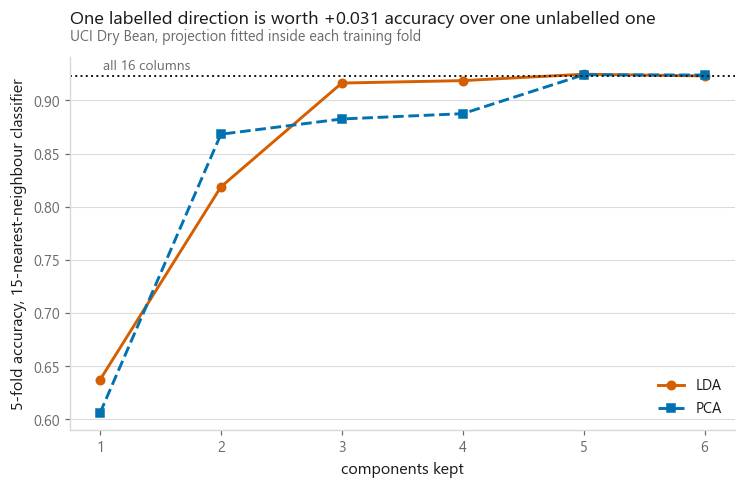

In [18]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
for name, colour, marker, dash in [("LDA", style.HIGHLIGHT, style.MARKERS[0], "-"),
                                   ("PCA", style.PALETTE[0], style.MARKERS[1], "--")]:
    ax.plot(components, curves[name], color=colour, marker=marker, ls=dash, label=name)
ax.axhline(all_columns, color=style.INK, ls=":", lw=1.3)
ax.annotate(f"all {d_bean} columns", xy=(components[0], all_columns), xytext=(2, 4),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xticks(components)
ax.set_xlabel("components kept")
ax.set_ylabel("5-fold accuracy, 15-nearest-neighbour classifier")
ax.legend(loc="lower right")
gap = curves["LDA"][0] - curves["PCA"][0]
style.title(ax, f"One labelled direction is worth {gap:+.3f} accuracy over one unlabelled one",
            "UCI Dry Bean, projection fitted inside each training fold")
style.save(fig, FIG / "fig-04-lda-vs-pca.png")

Read the `LDA minus PCA` column from top to bottom. The question is whether the
advantage of using labels is constant, or concentrated where the budget is tight,
and here is the answer.

It is neither, and the row that says so is the second one. At two components PCA
wins, and it wins by the largest margin anywhere in the column, larger than LDA's
own lead at one component. That is the opposite of "labels help most when the
budget is tightest", and it is the first thing to read off the table rather than
the last.

Around it the column does behave: LDA ahead at one component, PCA ahead at two,
LDA ahead again at three and four by roughly the size of its lead at one, and from
five onwards the two sit within a thousandth of each other in both directions. So
the labels are worth something at one direction, worth less than nothing at two,
worth something again at three and four, and worth nothing at all past that. The
narrowing I expected is real at the bottom of the column, because sixteen
correlated bean measurements do not hold sixteen independent things to find and a
handful of principal components eventually carry whatever LDA was picking out.
What I did not expect was that the column changes sign twice on the way down.

The two-component reversal is worth not smoothing over. LDA maximises separation
between class means relative to within-class scatter, which is not the same
objective as "leave the 15 nearest neighbours of a point inside the same variety",
and at two directions the difference between the two objectives is large enough to
decide the comparison. Whatever LDA's second direction is buying, a
15-nearest-neighbour classifier wants PCA's second direction more.

Two caveats, both of which the chart cannot show.

LDA's ceiling is $K-1$ components. If you want ten dimensions out of a two-class
problem, LDA has exactly one to offer and PCA has as many as you like.

LDA needs labels, so it cannot be used on the unlabelled pile. PCA can be fitted
on everything you have and applied to whatever arrives later.

The projections themselves are worth looking at directly.

columns weighing most on the first principal component:
MajorAxisLength    0.326
ShapeFactor2       0.315
Perimeter          0.311
EquivDiameter      0.297
ConvexArea         0.283

variance explained by the first two components: 0.8190


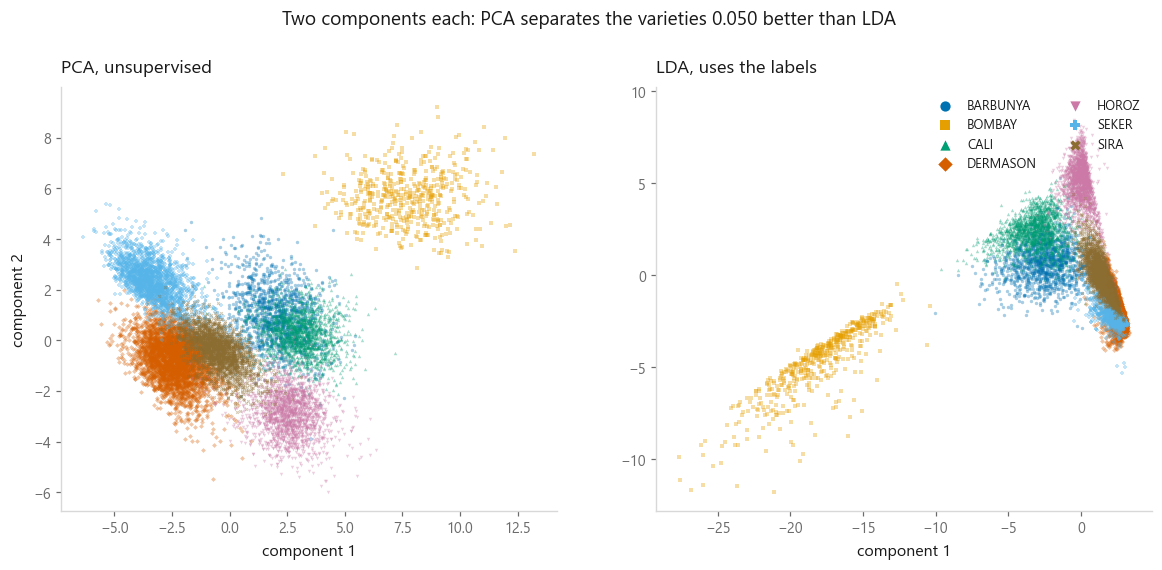

In [19]:
scaled = StandardScaler().fit_transform(X_bean.values)
pca_2 = PCA(n_components=2, random_state=SEED).fit(scaled)
projections = {
    "PCA, unsupervised": pca_2.transform(scaled),
    "LDA, uses the labels": LinearDiscriminantAnalysis(n_components=2).fit_transform(
        scaled, y_bean.values),
}

# What is the unsupervised direction actually made of? The loadings say so, and
# they are the reason the two panels below look as different as they do.
loadings = pd.Series(np.abs(pca_2.components_[0]), index=X_bean.columns)
print("columns weighing most on the first principal component:")
print(loadings.sort_values(ascending=False).head(5).round(3).to_string())
print(f"\nvariance explained by the first two components: "
      f"{pca_2.explained_variance_ratio_[:2].sum():.4f}")

variety_names = sorted(y_bean.unique())
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))
for ax, (name, flat) in zip(axes, projections.items()):
    for i, variety in enumerate(variety_names):
        sel = (y_bean == variety).values
        ax.scatter(flat[sel, 0], flat[sel, 1], s=5, alpha=0.35, linewidths=0,
                   c=style.PALETTE[i % len(style.PALETTE)],
                   marker=style.MARKERS[i % len(style.MARKERS)], label=variety)
    ax.set_xlabel("component 1")
    ax.grid(False)
    style.title(ax, name)

axes[0].set_ylabel("component 2")
legend = axes[1].legend(loc="upper right", markerscale=3, fontsize=8.5, ncol=2)
for handle in legend.legend_handles:
    handle.set_alpha(1)
# The sign of this gap is the finding, so the sentence is built from it rather than
# written first and handed a number afterwards.
two_component_gap = curves["LDA"][1] - curves["PCA"][1]
ahead, behind = ("LDA", "PCA") if two_component_gap > 0 else ("PCA", "LDA")
fig.suptitle(f"Two components each: {ahead} separates the varieties "
             f"{abs(two_component_gap):.3f} better than {behind}",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-projections.png")

PCA spreads the beans along the direction of largest variance, and the printed
loadings name which measurements built that direction. The varieties then smear
across it, because nothing in the fit was told that varieties exist. LDA pulls
the class means apart while squeezing the within-class spread, so the same seven
clouds arrive already sorted. Neither picture is wrong; they were asked different
questions.

And the suptitle is the reason to be careful with that reading. The right-hand
panel looks more sorted and it is the one that scores lower, by the printed
margin. Looking separated to a reader and being separable by a nearest-neighbour
rule are different properties, and at two components they come apart.

## 5. When it wins, when it loses

Now the measurement the chapter exists for. Two regimes, ten dimensions, one
large training set each, and a large fresh test set. Theory says LDA should win
where covariances are shared and QDA should win where they are not.

In [20]:
X_test_shared, y_test_shared = draw(*SHARED_ND, 10_000, seed=201)
X_test_unequal, y_test_unequal = draw(*UNEQUAL_ND, 10_000, seed=202)

regimes = {"shared covariance": (SHARED_ND, X_test_shared, y_test_shared),
           "unequal covariance": (UNEQUAL_ND, X_test_unequal, y_test_unequal)}

PLENTY_PER_CLASS = 3000

plenty = []
for name, (params, X_eval, y_eval) in regimes.items():
    X_fit, y_fit = draw(*params, PLENTY_PER_CLASS, seed=203)
    for label, model in [("LDA", LinearDiscriminantAnalysis()),
                         ("QDA", QuadraticDiscriminantAnalysis())]:
        plenty.append({"regime": name, "model": label,
                       "accuracy": model.fit(X_fit, y_fit).score(X_eval, y_eval)})

plenty = pd.DataFrame(plenty).pivot(index="regime", columns="model", values="accuracy")
plenty["winner"] = np.where(plenty["QDA"] > plenty["LDA"], "QDA", "LDA")
print(f"training set: {PLENTY_PER_CLASS:,} points per class in {D} dimensions\n")
print(plenty.round(4).to_string())

as_predicted = (plenty.loc["shared covariance", "winner"] == "LDA"
                and plenty.loc["unequal covariance", "winner"] == "QDA")
print(f"\neach method won where its assumption holds: {as_predicted}")
print(f"QDA's margin in the shared regime, where its extra flexibility is useless: "
      f"{plenty.loc['shared covariance', 'QDA'] - plenty.loc['shared covariance', 'LDA']:+.4f}")
print(f"QDA's margin in the unequal regime, where it is not: "
      f"{plenty.loc['unequal covariance', 'QDA'] - plenty.loc['unequal covariance', 'LDA']:+.4f}")

training set: 3,000 points per class in 10 dimensions

model                  LDA     QDA winner
regime                                   
shared covariance   0.8714  0.8722    QDA
unequal covariance  0.6768  0.8507    QDA

each method won where its assumption holds: False
QDA's margin in the shared regime, where its extra flexibility is useless: +0.0009
QDA's margin in the unequal regime, where it is not: +0.1740


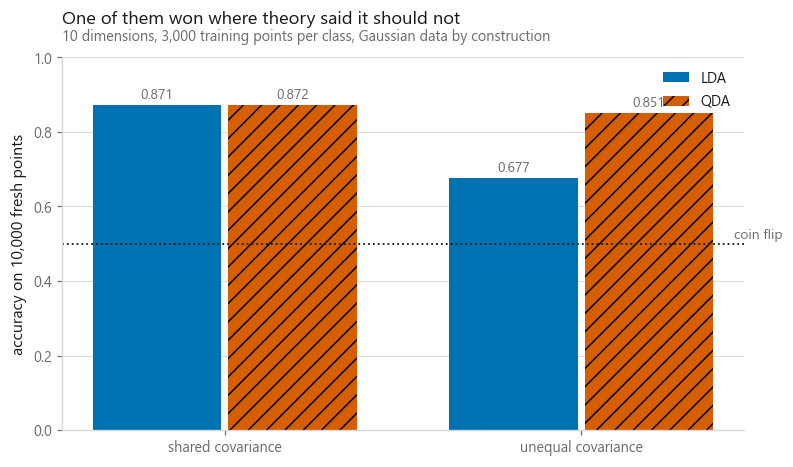

In [21]:
fig, ax = plt.subplots(figsize=(8.0, 4.4))
positions = np.arange(len(plenty))
for offset, model, colour, hatch in [(-0.19, "LDA", style.PALETTE[0], ""),
                                     (0.19, "QDA", style.HIGHLIGHT, "//")]:
    ax.bar(positions + offset, plenty[model], width=0.36, color=colour,
           hatch=hatch, label=model)
    for x, value in zip(positions + offset, plenty[model]):
        ax.annotate(f"{value:.3f}", xy=(x, value), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=9, color=style.MUTED)
ax.axhline(0.5, color=style.INK, ls=":", lw=1.2)
ax.annotate("coin flip", xy=(positions[-1] + 0.42, 0.5), xytext=(2, 3),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xticks(positions, plenty.index)
ax.set_ylim(0, 1.0)
ax.set_ylabel("accuracy on 10,000 fresh points")
ax.legend(loc="upper right")
style.title(ax, "Each method wins where its assumption holds"
                if as_predicted else "One of them won where theory said it should not",
            f"{D} dimensions, {PLENTY_PER_CLASS:,} training points per class, "
            f"Gaussian data by construction")
style.save(fig, FIG / "fig-06-assumption-match.png")

Read the line under the table before the chart. It says `False`, and the reason
is the shared regime: QDA won there too, on data built to be exactly what LDA
assumes. The two printed margins are the whole story. Where shape carries the
separation QDA takes a large lead, and where shape carries nothing it still
takes a small one, because with a training set this size the extra covariance
parameters cost almost nothing to estimate.

That is the easy half. Flexibility you do not need is close to free when you can
afford it, so the interesting question is never whether the assumption is right.
It is whether you can pay for it.

### The half nobody mentions

Keep the unequal-covariance regime, where QDA's assumption is **correct**, and
shrink the training set. I built this sweep expecting a crossover: LDA ahead at
small sizes, QDA overtaking it somewhere, on the reasoning that a hundred and ten
covariance numbers estimated from a handful of rows are mostly noise. The printed
sweep has no crossover in it. From the first size at which QDA returns a model at
all, it leads, and the smallest of its margins is at that first size.

What does bite is the other thing entirely. Below some number of rows per class
the class covariance cannot be full rank for arithmetic reasons alone, and QDA
does not score badly there, it refuses. The binding constraint on this data is
whether QDA can be fitted, not whether it wins once it has been.

That refusal is the synthetic twin of section 4, and the two are worth keeping
apart. There the covariance was singular at every sample size, because the columns
were functions of one another. Here it is singular only while there are too few
rows, and it becomes usable the moment there are enough. The count of refused fits
below separates the two.

In [22]:
# The grid starts below D on purpose. Section 4's failure has a synthetic twin:
# with fewer rows than columns in a class, the covariance cannot be full rank for
# arithmetic reasons alone, and QDA refuses again.
sizes = [6, 8, 11, 15, 20, 30, 45, 70, 110, 175, 280, 450, 700, 1100, 1800]
REPEATS = 30

curve = {"LDA": [], "QDA": []}
bands = {"LDA": [], "QDA": []}
refused = 0

for n in sizes:
    per_model = {"LDA": [], "QDA": []}
    for repeat in range(REPEATS):
        X_fit, y_fit = draw(*UNEQUAL_ND, n, seed=1000 + 17 * repeat + n)
        per_model["LDA"].append(
            LinearDiscriminantAnalysis().fit(X_fit, y_fit).score(X_test_unequal, y_test_unequal))
        try:
            per_model["QDA"].append(
                QuadraticDiscriminantAnalysis().fit(X_fit, y_fit).score(X_test_unequal, y_test_unequal))
        except np.linalg.LinAlgError:
            # The section 4 failure, if it were going to reappear, would reappear here.
            refused += 1
            per_model["QDA"].append(np.nan)
    for label in curve:
        scored = [v for v in per_model[label] if not np.isnan(v)]
        curve[label].append(np.mean(scored) if scored else np.nan)
        bands[label].append(np.std(scored) if scored else np.nan)

sweep = pd.DataFrame({"n per class": sizes, "LDA": curve["LDA"], "QDA": curve["QDA"]})
sweep["QDA minus LDA"] = sweep["QDA"] - sweep["LDA"]
print(f"fits attempted per model: {len(sizes) * REPEATS}")
print(f"QDA fits refused outright, no model returned: {refused}\n")
print(sweep.round(4).to_string(index=False, na_rep="refused to fit"))

fittable = sweep.dropna()
floor = int(fittable["n per class"].iloc[0])
losing = fittable[fittable["QDA minus LDA"] <= 0]["n per class"]
crossover = None if losing.empty else int(losing.iloc[-1])

print(f"\nsmallest training size where QDA returns a model at all: {floor} per class, "
      f"against {D} columns")
if crossover is None:
    headline = f"Below {floor} rows per class QDA has no model, and above it never trails"
    print(f"once it fits, QDA leads at every size tested, by "
          f"{fittable['QDA minus LDA'].min():+.4f} at worst")
else:
    headline = f"QDA's correct assumption only pays above {crossover} rows per class"
    print(f"QDA still trails LDA up to {crossover} rows per class "
          f"({crossover * 2} training rows for {parameter_count(D, 2)['QDA']} QDA parameters)")

# The bands on the next chart, as numbers, because the mean is the easy half and I
# had the other half backwards until I printed it.
both_fit = [i for i in range(len(sizes)) if not np.isnan(bands["QDA"][i])]
lda_wider = sum(bands["LDA"][i] > bands["QDA"][i] for i in both_fit)
print(f"\nstandard deviation across the {REPEATS} draws, at the {len(both_fit)} sizes "
      f"where both models fit:")
print(f"  LDA's is the wider of the two at {lda_wider} of {len(both_fit)}")
for i in [both_fit[0], both_fit[-1]]:
    print(f"  n={sizes[i]:<5} LDA {bands['LDA'][i]:.4f}   QDA {bands['QDA'][i]:.4f}   "
          f"ratio {bands['LDA'][i] / bands['QDA'][i]:.2f}x")

fits attempted per model: 450
QDA fits refused outright, no model returned: 65

 n per class    LDA            QDA  QDA minus LDA
           6 0.5298 refused to fit refused to fit
           8 0.5451 refused to fit refused to fit
          11 0.5664         0.5780         0.0116
          15 0.5915         0.6579         0.0664
          20 0.6022         0.6860         0.0839
          30 0.6246         0.7593         0.1347
          45 0.6353         0.7818         0.1465
          70 0.6522         0.8087         0.1565
         110 0.6604         0.8227         0.1623
         175 0.6663         0.8337         0.1674
         280 0.6712         0.8409         0.1697
         450 0.6739         0.8457         0.1718
         700 0.6775         0.8478         0.1703
        1100 0.6777         0.8493         0.1717
        1800 0.6783         0.8506         0.1723

smallest training size where QDA returns a model at all: 11 per class, against 10 columns
once it fits, QDA leads at ev

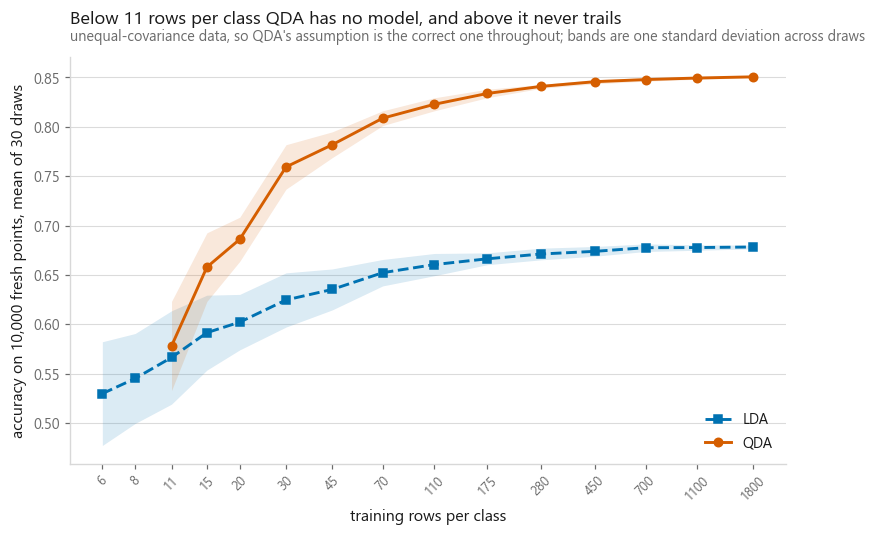

In [23]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for name, colour, marker, dash in [("LDA", style.PALETTE[0], style.MARKERS[1], "--"),
                                   ("QDA", style.HIGHLIGHT, style.MARKERS[0], "-")]:
    values, band = np.array(curve[name]), np.array(bands[name])
    ax.plot(sizes, values, color=colour, marker=marker, ls=dash, label=name)
    ax.fill_between(sizes, values - band, values + band, color=colour, alpha=0.14, linewidth=0)

if crossover is not None:
    ax.axvline(crossover, color=style.INK, ls=":", lw=1.3)
    ax.annotate(f"QDA takes the lead\nat {crossover} per class", xy=(crossover, min(curve["LDA"])),
                xytext=(6, 6), textcoords="offset points", fontsize=9, color=style.MUTED)

ax.set_xscale("log")
ax.set_xticks(sizes, [str(s) for s in sizes], rotation=45, fontsize=8.5)
ax.minorticks_off()
ax.set_xlabel("training rows per class")
ax.set_ylabel(f"accuracy on 10,000 fresh points, mean of {REPEATS} draws")
ax.legend(loc="lower right")
style.title(ax, headline,
            "unequal-covariance data, so QDA's assumption is the correct one throughout; "
            "bands are one standard deviation across draws")
style.save(fig, FIG / "fig-07-sample-size.png")

The number to take from that sweep is the one the printout calls the smallest
training size where QDA returns a model at all. I expected it to sit well above
the column count, on the reasoning that estimable and well estimated are
different standards and only the second one wins accuracy. It sits barely above
the column count, and from there QDA is ahead at every size on the grid. On this
data the two standards turn out to be nearly the same threshold, and everything
below it is not a worse model but no model.

The shaded bands are the part I got wrong before I printed them. The reasoning was
the standard one: more parameters means more sensitivity to which particular rows
you happened to draw, so QDA's band should be the wider one and QDA should be the
better bet on average while being the riskier one to run once.

The printed standard deviations say the opposite, at every size where both models
fit, and the chart agrees with them. LDA's band is the wider one throughout, and
the ratio grows rather than shrinks as rows are added, so this is not a small-data
artefact that washes out.

The reading I would offer is that the standard reasoning is about the variance of
the parameter estimates, and the band here is the variance of the resulting
accuracy, which is a different quantity. In this regime the classes have nearly
the same centre, so the mean difference LDA is estimating is faint and the
boundary it draws swings with the draw while the accuracy it earns stays near the
bottom of the chart. QDA is estimating a difference in shape, which in this data
is loud, and once it has enough rows to see it the answer stops moving. More
parameters cost variance; a signal that is barely there costs more.

So the mean is the part people quote and the spread is the part that ruins an
afternoon, and here QDA is ahead on both. Which is a reason to print the spread
rather than to infer it from the parameter count.

A practical reading. When somebody tells you their model's assumptions match the
data, ask how many rows they have per parameter, and ask it as a question about
whether the fit exists at all rather than about whether it wins. The failure mode
on this sweep was not a correct assumption losing. It was a correct assumption
with nothing to return.

The escape hatch, in both this failure and the one in section 4, is the same
dial. Sit between the two models rather than choosing one. Sections 4 and 5
arrive at that from opposite directions, one from a matrix that cannot be
inverted and one from a matrix that can be inverted and is not worth much, which
is a good sign that the advice is the real one.

## Cheat sheet

| | |
|---|---|
| **Use LDA when** | Classes look like the same cloud in different places, you have few rows per feature, the columns are redundant, or you want a supervised projection into $K-1$ dimensions |
| **Use QDA when** | Class clouds genuinely differ in shape or orientation **and** you have enough rows per class to estimate a covariance matrix each **and** those rows point in enough independent directions |
| **Avoid both when** | Features are heavily non-Gaussian, or the classes overlap in a way no ellipse describes. Then reach for [trees](../06-decision-trees/) or [SVMs](../05-support-vector-machines/) |
| **Scaling needed** | Not for the classifier in principle: the covariance already absorbs units. In practice the rank check is an absolute tolerance, so wildly different units can fail it on their own. Yes for the projection if you plan to read the loadings, and yes if you compare against PCA |
| **Main dials** | `shrinkage` with `solver="lsqr"` for LDA, `reg_param` for QDA. Note what each shrinks towards: `reg_param` pulls to a sphere, not to LDA |
| **Watch out** | Redundant columns do not make QDA worse, they make it refuse. `LinAlgError: the covariance matrix of class ... is not full rank` is that refusal, and it is a statement about your columns rather than about your code. The class it names is the first one checked, not the worst one in the table |
| **Relatives** | Gaussian naive Bayes is QDA with the off-diagonals set to zero, which is also why it survives data QDA cannot fit. Logistic regression fits the same linear log-odds as LDA, discriminatively rather than generatively |
| **Next** | [Support vector machines](../05-support-vector-machines/), which drop the density model entirely and fit the boundary directly |

## What to remember

1. Both methods model each class as a Gaussian and pick the class with the
   largest log posterior. The only difference is whether the covariance is shared.
2. Sharing the covariance cancels the quadratic term and the log-determinant,
   which is why LDA's boundary is straight. The cancellation is in the algebra,
   not in the code.
3. QDA's parameter count grows with the number of classes times $d^2$. That bill
   comes due on small data.
4. QDA can fail before it is scored at all. When columns are functions of other
   columns, the class covariance has no extent in some directions and there is
   nothing to invert. The printed spectra show exactly which directions those are.
   The class named in the exception is the first one checked, not the worst one.
5. Rows per class is the wrong diagnostic for that failure. Dry Bean's smallest
   class has many times more rows than columns and still cannot be fitted.
6. LDA survives the same data for two reasons, and only one is about statistics.
   Pooling improves the conditioning by the printed factor, and scikit-learn's
   LDA also drops unusable directions where its QDA raises.
7. On the section 5 sweep the constraint was arithmetic rather than statistical.
   Below the printed floor QDA has no model to score, and from that floor upwards
   its correct assumption paid at every size tested. Ask whether the fit exists
   before asking whether it wins.
8. Report the spread across resamples as well as the mean, and read it off the
   measurement rather than off the parameter count. On this sweep the model with
   more parameters had the narrower band at every size where both fitted, because
   the difference LDA was estimating was fainter than the difference QDA was
   estimating.
9. Regularised discriminant analysis is the answer to both failures, and the best
   setting on Dry Bean is strictly between QDA and LDA. Check what your dial
   shrinks towards: `reg_param` shrinks to a sphere and does not reach LDA.
10. LDA doubles as a supervised projection into at most $K-1$ dimensions. Access
   to the labels is worth something at one component, worth less than nothing at
   two, where PCA takes the largest gap in the printed column, and worth nothing
   either way past four. Read that column instead of assuming the supervised
   projection wins wherever the budget is tight.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-05 Support Vector Machines](../05-support-vector-machines/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#LDA` `#QDA` `#DiscriminantAnalysis` `#Classification`
`#DimensionalityReduction` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`